# Обучение моделей для пословной разметки. mBERT

Для обучение используется датасет KazRusCSW-G-T.

Тегсет:
- kz – слова казахского языка.
- skz – слова казахского языка, транслитерированные на кириллице русского языка (биздин вместо “біздің”).
- ru – слова русского языка.
- other – слова из третьего языка, имена собственные, написанные на латинице и не принадлежащие к какому-либо языку (Google, Wolt), общепринятые сокращения на латинице (lol, p.s., upd), а также транслитерации с третьего языка (бро от “bro”, сейфети от “safety”).
- mixed__kz-ru, mixed__ru-kz – слова, в которых сочетаются морфемы из двух языков (казахский корень + русское окончание – mixed__kz-ru; русский корень + казахское окончание – mixed__ru-kz).
- ambig – слова, существующие в обоих языках, и имеющие одинаковое семантическое и синтаксическое значение. Например, "атом" в роли подлежащего – ambig, но в словосочетании “атом электр станциясы” (пер. атомная электростанция) –  kz. Омонимы, например, "не" и "бар" размечались также в зависимости от контекста. Данным тегом также помечались имена собственные, написанные на кириллице и имеющие одинаковое написание на обоих языках (Яндекс, Годзилла, Джордж Оруэлл).
- univ – числа, пунктуация и переносы строк, замаскированные номера и упоминания, обозначения, включающие цифры, например “гаплогруппа R1A1”.

In [ ]:
import pandas as pd

df = pd.read_json('KazRusCSW-G-T.jsonl', lines=True)
df


,id,text,Comments,cats,entities,tokens,spans,tags,split
0,0,"""Близок логоть, да не укусишь"" жардың ғой хпхп...",[],[],"[[0, 1, univ], [1, 7, ru], [8, 14, ru], [14, 1...","["", Близок, логоть, ,, да, не, укусишь, "", жар...","[[0, 1], [1, 7], [8, 14], [14, 15], [16, 18], ...","[univ, ru, ru, univ, ru, ru, ru, univ, kz, kz,...",test
1,1,"""Вот как выглядят лучшие дороги Жаңа Қазақстан""",[],[],"[[0, 1, univ], [1, 4, ru], [5, 8, ru], [9, 17,...","["", Вот, как, выглядят, лучшие, дороги, Жаңа, ...","[[0, 1], [1, 4], [5, 8], [9, 17], [18, 24], [2...","[univ, ru, ru, ru, ru, ru, kz, kz, univ]",train
2,2,"""Высокий, красивый, статный"" ресейліктермен не...",[],[],"[[0, 1, univ], [1, 8, ru], [8, 9, univ], [10, ...","["", Высокий, ,, красивый, ,, статный, "", ресей...","[[0, 1], [1, 8], [8, 9], [10, 18], [18, 19], [...","[univ, ru, univ, ru, univ, ru, univ, kz, kz, k...",train
3,3,"""Добрый день, доны! Давеча побывал у данной фе...",[],[],"[[0, 1, univ], [1, 7, ru], [8, 12, ru], [12, 1...","["", Добрый, день, ,, доны, !, Давеча, побывал,...","[[0, 1], [1, 7], [8, 12], [12, 13], [14, 18], ...","[univ, ru, ru, univ, ru, univ, ru, ru, ru, ru,...",train
4,4,"""Дүние құрысын, мысығым тірі екен"" - Житель ЗК...",[],[],"[[0, 1, univ], [1, 6, kz], [7, 14, kz], [14, 1...","["", Дүние, құрысын, ,, мысығым, тірі, екен, "",...","[[0, 1], [1, 6], [7, 14], [14, 15], [16, 23], ...","[univ, kz, kz, univ, kz, kz, kz, univ, univ, r...",train
...,...,...,...,...,...,...,...,...,...
3203,3211,Ийэ по-якутски «мама». Очень интересная паралл...,[],[],"[[0, 3, other], [4, 6, ru], [6, 7, univ], [7, ...","[Ийэ, по, -, якутски, «, мама, », ., Очень, ин...","[[0, 3], [4, 6], [6, 7], [7, 14], [15, 16], [1...","[other, ru, univ, ru, univ, ru, univ, univ, ru...",test
3204,3212,А в якому році в Середній Азіїї приняли іслам?...,[],[],"[[0, 1, other], [2, 3, other], [4, 9, other], ...","[А, в, якому, році, в, Середній, Азіїї, принял...","[[0, 1], [2, 3], [4, 9], [10, 14], [15, 16], [...","[other, other, other, other, other, other, oth...",train
3205,3213,Почему на русском?\nКазакша суйлөйбөйсүңөрбү,[],[],"[[0, 6, ru], [7, 9, ru], [10, 17, ru], [17, 18...","[Почему, на, русском, ?, \n, Казакша, суйлөйбө...","[[0, 6], [7, 9], [10, 17], [17, 18], [18, 20],...","[ru, ru, ru, univ, univ, other, other]",train
3206,3214,"В данном случае будет Ысырап, а не Обал!\nОбал...",[],[],"[[0, 1, ru], [2, 8, ru], [9, 15, ru], [16, 21,...","[В, данном, случае, будет, Ысырап, ,, а, не, О...","[[0, 1], [2, 8], [9, 15], [16, 21], [22, 28], ...","[ru, ru, ru, ru, kz, univ, ru, ru, kz, univ, u...",train


## Data prep

In [ ]:
# собираем уникальные теги из разметки
res = set()
df['tags'].apply(lambda l: res.update(l))
res

{'ambig', 'kz', 'mixed_kz-ru', 'mixed_ru-kz', 'other', 'ru', 'skz', 'univ'}

In [ ]:
id2label = dict(zip(range(len(res)), sorted(res)))
id2label

{0: 'ambig',
 1: 'kz',
 2: 'mixed_kz-ru',
 3: 'mixed_ru-kz',
 4: 'other',
 5: 'ru',
 6: 'skz',
 7: 'univ'}

In [ ]:
label2id = {v: k for k, v in id2label.items()}
label2id

{'ambig': 0,
 'kz': 1,
 'mixed_kz-ru': 2,
 'mixed_ru-kz': 3,
 'other': 4,
 'ru': 5,
 'skz': 6,
 'univ': 7}

In [ ]:
def tag2id(lst):
    """
    Заменяем теги на их id
    """
    res = []
    for tag in lst:
        res.append(label2id[tag])
    return res
df['tags_i'] = df['tags'].apply(tag2id)
df['tags_i']

,tags_i
0,"[7, 5, 5, 7, 5, 5, 5, 7, 1, 1, 0]"
1,"[7, 5, 5, 5, 5, 5, 1, 1, 7]"
2,"[7, 5, 7, 5, 7, 5, 7, 1, 1, 1, 1]"
3,"[7, 5, 5, 7, 5, 7, 5, 5, 5, 5, 5, 7, 1, 1]"
4,"[7, 1, 1, 7, 1, 1, 1, 7, 7, 5, 5, 5, 7, 5, 5, ..."
...,...
3203,"[4, 5, 7, 5, 7, 5, 7, 7, 5, 5, 5, 5, 7, 5, 7, 7]"
3204,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 7, 7, 7, 7, 4, 4, ..."
3205,"[5, 5, 5, 7, 7, 4, 4]"
3206,"[5, 5, 5, 5, 1, 7, 5, 5, 1, 7, 7, 1, 5, 5, 5, ..."


### Training

In [ ]:
from datasets import Dataset, DatasetDict

In [ ]:
train_data = Dataset.from_pandas(df[df['split']=='train'][['tags_i', 'tokens']])
test_data = Dataset.from_pandas(df[df['split']=='test'][['tags_i', 'tokens']])

data = DatasetDict({
    'train': train_data,
    'test': test_data,
})

In [ ]:
data

DatasetDict({
    train: Dataset({
        features: ['tags_i', 'tokens', '__index_level_0__'],
        num_rows: 2566
    })
    test: Dataset({
        features: ['tags_i', 'tokens', '__index_level_0__'],
        num_rows: 642
    })
})

In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer

model_path = 'google-bert/bert-base-multilingual-cased'

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForTokenClassification.from_pretrained(
    model_path, num_labels=len(id2label), id2label=id2label, label2id=label2id
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params we

In [ ]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples[f"tags_i"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

tokenized_data = data.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/2566 [00:00<?, ? examples/s]

Map:   0%|          | 0/642 [00:00<?, ? examples/s]

In [ ]:
tokenizer.all_special_tokens

['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']

In [ ]:
# добавляем в качестве специальных токенов маски и перенос строки
print('special tokens before the update:', len(tokenizer))
num_added_toks = tokenizer.add_tokens(['[MENTION]', '[NUMBER]', '[HASHTAG]', '[EMOJI]', '[LINK]', '[EMAIL]', '\\n'], special_tokens=True)
model.resize_token_embeddings(len(tokenizer))
print('special tokens after the update:', len(tokenizer))

special tokens before the update: 119547


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


special tokens after the update: 119554


In [ ]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

In [ ]:
!pip install evaluate
!pip install seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=4c1c282f0a295e8db2cdd49ebd1d001114f28e356fdeba6245297a9dffbbcb0f
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [ ]:
import evaluate

seqeval = evaluate.load("seqeval")

In [ ]:
import numpy as np

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [ ]:
finetuned_model_path = 'KazRusCSW-mbert'

training_args = TrainingArguments(
    output_dir='_'+finetuned_model_path,
    learning_rate=1e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.250346,0.166559,0.860568,0.854954,0.857752,0.952765
2,0.162864,0.152085,0.869309,0.871947,0.870626,0.957734
3,0.125915,0.164718,0.891577,0.872098,0.881730,0.960767
4,0.071675,0.157953,0.888228,0.883781,0.885999,0.962057
5,0.069894,0.165917,0.884885,0.879381,0.882125,0.961412


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: univ seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ru seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: kz seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ambig seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: mixed_ru-kz seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: univ seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ru seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: kz seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ambig seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: mixed_ru-kz seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: univ seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ru seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: kz seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: ambig seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: mixed_ru-kz seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3210, training_loss=0.12687638214444075, metrics={'train_runtime': 686.0356, 'train_samples_per_second': 18.702, 'train_steps_per_second': 4.679, 'total_flos': 739318034356608.0, 'train_loss': 0.12687638214444075, 'epoch': 5.0})

In [ ]:
model.save_pretrained(finetuned_model_path)
tokenizer.save_pretrained(finetuned_model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('KazRusCSW_mbert_/tokenizer_config.json', 'KazRusCSW_mbert_/tokenizer.json')

In [ ]:
!zip -r KazRusCSW-mbert.zip {finetuned_model_path}

  adding: KazRusCSW_mbert/ (stored 0%)
  adding: KazRusCSW_mbert/tokenizer.json (deflated 67%)
  adding: KazRusCSW_mbert/tokenizer_config.json (deflated 43%)
  adding: KazRusCSW_mbert/config.json (deflated 57%)
  adding: KazRusCSW_mbert/model.safetensors (deflated 7%)


### Evaluation

In [ ]:
import torch
from transformers import AutoModelForTokenClassification
from transformers import AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

finetuned_model_path = 'KazRusCSW-mbert'

tokenizer = AutoTokenizer.from_pretrained(finetuned_model_path)
model = AutoModelForTokenClassification.from_pretrained(finetuned_model_path).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
import torch.nn.functional as F
import torch
text = [
    ['это', 'предложение', 'на', 'русском', 'языке'],
    ['сызықтық', 'рангтің', 'бірізді', 'статистикасы']
    ]

inputs = tokenizer(text, return_tensors="pt", is_split_into_words=True, truncation=True, padding=True).to(device)

with torch.no_grad():
    logits = model(**inputs).logits
# predictions = torch.argmax(logits, dim=-1)
probs = torch.max(F.softmax(logits, dim=-1), dim=-1)

for sent_, tokens_, labels_ in zip(text, inputs["input_ids"], probs.indices):
    predicted_token_class = [model.config.id2label[t.item()] for t in labels_]
    print(predicted_token_class)
    # ['univ', 'kz', 'kz', 'kz', 'kz', 'kz', 'kz', 'kz', 'kz', 'kz', 'univ']
    tokens = tokenizer.convert_ids_to_tokens(tokens_)
    print(tokens)

['univ', 'ru', 'ru', 'ru', 'ru', 'ru', 'univ', 'univ', 'univ', 'univ', 'univ']
['[CLS]', 'это', 'предложение', 'на', 'русском', 'языке', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['univ', 'kz', 'kz', 'kz', 'kz', 'kz', 'kz', 'kz', 'kz', 'kz', 'univ']
['[CLS]', 'с', '##ызы', '##қты', '##қ', 'ранг', '##тің', 'бірі', '##зді', 'статистикасы', '[SEP]']


In [ ]:
import torch.nn.functional as F
def predict_labels(examples):
    inputs_ = tokenizer(examples["tokens"], return_tensors="pt", is_split_into_words=True, truncation=True, padding=True).to(device)
    with torch.no_grad():
        logits = model(**inputs_).logits
    # predictions = torch.argmax(logits, dim=-1)
    probs = torch.max(F.softmax(logits, dim=-1), dim=-1)

    all_words = []
    all_labels = []
    all_probas = []

    for i, word_ids in enumerate(inputs_['input_ids']):
        row_words = []
        row_labels = []
        row_probas = []
        words = tokenizer.convert_ids_to_tokens(word_ids)
        for j, (word_idx, word) in enumerate(zip(word_ids, words)):  # Set the special tokens to -100.
            if word.startswith('##'):
                # print('subtoken', word_idx, word)
                row_words[-1] = row_words[-1] + word[2:]
            elif word not in ('[SEP]', '[PAD]', '[CLS]'):
                # print('starting subtoken', word_idx, word)
                row_words.append(word)
                row_labels.append(probs.indices[i, j])
                row_probas.append(probs.values[i, j])
            # else:
            #     # print('skipping', word_idx, word)
            #     pass

        # if len(examples["tokens"][i]) != len(row_words):
        #     print(f'word number mismatch! id={i}')

        all_words.append(row_words)
        all_labels.append(row_labels)
        all_probas.append(row_probas)

    inputs_["words"] = all_words
    inputs_["labels"] = all_labels
    inputs_["probas"] = all_probas

    return inputs_


from datasets import Dataset
import datetime

print(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"), 'Starting inference...')

y_pred = data['test'].map(predict_labels, batched=True, batch_size=4)
print(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"), 'Inference finished')

2026-05-21 21:18:30 Starting inference...


Map:   0%|          | 0/642 [00:00<?, ? examples/s]

2026-05-21 21:18:55 Inference finished


In [ ]:
preds = pd.DataFrame(y_pred)
preds

,tags_i,tokens,__index_level_0__,input_ids,token_type_ids,attention_mask,words,labels,probas
0,"[7, 5, 5, 7, 5, 5, 5, 7, 1, 1, 0]","["", Близок, логоть, ,, да, не, укусишь, "", жар...",0,"[101, 107, 510, 10783, 58607, 10510, 30977, 10...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","["", Близок, логоть, ,, да, не, укусишь, "", жар...","[7, 5, 5, 7, 5, 5, 5, 7, 1, 1, 0]","[0.9994760155677795, 0.9978799819946289, 0.998..."
1,"[7, 5, 5, 5, 7, 1, 1, 7, 1, 1, 1, 1, 1]","["", Оседлый, образ, жизни, "", болады, орысша, ...",14,"[101, 107, 523, 13110, 10746, 48276, 52515, 17...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","["", Оседлый, образ, жизни, "", болады, орысша, ...","[7, 5, 5, 5, 7, 1, 1, 7, 1, 1, 1, 1, 1]","[0.9995245933532715, 0.9945864677429199, 0.703..."
2,"[7, 5, 5, 5, 5, 5, 5, 7, 1, 1, 7, 1, 7, 1, 7, ...","["", Рабочая, неделя, завтра, подходит, к, конц...",17,"[101, 107, 525, 50889, 10316, 95156, 10375, 10...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","["", Рабочая, неделя, завтра, подходит, к, конц...","[7, 5, 5, 5, 5, 5, 5, 7, 1, 1, 7, 1, 7, 1, 7, ...","[0.9995662569999695, 0.997363269329071, 0.9371..."
3,"[7, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, 5, 5, 7, 5, ...","["", Этот, специалист, в, данный, момент, у, на...",22,"[101, 107, 35589, 558, 97516, 543, 71325, 2065...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","["", Этот, специалист, в, данный, момент, у, на...","[7, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, 5, 5, 7, 5, ...","[0.9995586276054382, 0.9985270500183105, 0.989..."
4,"[7, 1, 1, 1, 1, 1, 1, 7, 1, 1, 1, 1, 7, 0, 0, ...","["", Қазақ, ханы, Кенесары, ханды, Аллаһ, қорға...",25,"[101, 107, 18653, 26094, 10292, 519, 20516, 54...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","["", Қазақ, ханы, Кенесары, ханды, Аллаһ, қорға...","[7, 1, 1, 1, 1, 1, 1, 7, 1, 1, 5, 5, 7, 0, 0, ...","[0.9993541836738586, 0.9516100287437439, 0.838..."
...,...,...,...,...,...,...,...,...,...
637,"[7, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, ...","[[MENTION], Брат, я, понимаю, что, вы, хотите,...",3187,"[101, 119547, 98798, 572, 10297, 97582, 10593,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[MENTION], Брат, я, понимаю, что, вы, хотите,...","[7, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 7, ...","[0.9933386445045471, 0.9938911199569702, 0.998..."
638,"[4, 4, 4, 7, 4, 4, 4, 7, 4, 4, 7]","[Қозоғлар, капада, яшаганку, ., Қанақа, хонлик...",3188,"[101, 598, 44666, 10316, 111085, 13225, 56280,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[Қозоғлар, капада, яшаганку, ., Қанақа, хонлик...","[1, 4, 4, 7, 1, 4, 4, 7, 4, 4, 7]","[0.8884692788124084, 0.719722330570221, 0.6307..."
639,"[4, 4, 7, 4, 4, 7, 4, 4, 4, 4, 0, 4, 7]","[Сөпкө, хоруйдуур, !, мөлтөх, омукпут, ,, Саха...",3197,"[101, 526, 60761, 95983, 91690, 110247, 73211,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[Сөпкө, хоруйдуур, !, мөлтөх, омукпут, ,, Саха...","[4, 4, 7, 4, 4, 7, 4, 4, 4, 4, 0, 7, 7]","[0.5630780458450317, 0.730193555355072, 0.9991..."
640,"[5, 7, 5, 5, 5, 5, 7, 5, 5, 7, 4, 4, 4, 7, 5, ...","[Точно, !, Митинги, устраивать, с, лозунгами, ...",3201,"[101, 31217, 14757, 106, 84078, 25111, 14122, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[Точно, !, Митинги, устраивать, с, лозунгами, ...","[5, 7, 5, 5, 5, 5, 7, 5, 5, 7, 4, 4, 4, 7, 5, ...","[0.9989868998527527, 0.9993768334388733, 0.994..."


In [ ]:
preds[preds['words'].apply(len) != preds['tokens'].apply(len)]

,tags_i,tokens,__index_level_0__,input_ids,token_type_ids,attention_mask,words,labels,probas
37,"[5, 7, 1, 1, 5, 1, 5, 5, 5, 0, 5, 5, 5, 5, 5, ...","[Аллах, -, Бір, Құдай, Казахском, Тәңір, РУсск...",162,"[101, 26657, 26152, 118, 510, 20439, 598, 1110...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[Аллах, -, Бір, Құдай, Казахском, Тәңір, РУсск...","[0, 7, 1, 1, 5, 1, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[0.8882112503051758, 0.9992658495903015, 0.988..."


In [ ]:
from collections import Counter

id2label = model.config.id2label

y_true = []
y_pred = []


def calc_accuracy(row):
    true_labels = [id2label.get(x, 'UNK') for x in row['tags_i']]
    pred_labels = [id2label.get(x, 'UNK') for x in row['labels']]

    min_len = min(len(true_labels), len(pred_labels))

    y_true.extend(true_labels[:min_len])
    y_pred.extend(pred_labels[:min_len])

preds.apply(calc_accuracy, axis=1)

,0
0,None
1,None
2,None
3,None
4,None
...,...
637,None
638,None
639,None
640,None


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

       ambig     0.5664    0.7375    0.6407       480
          kz     0.9707    0.9559    0.9633      5448
 mixed_kz-ru     0.4615    0.1579    0.2353        38
 mixed_ru-kz     0.0000    0.0000    0.0000        15
       other     0.8992    0.7985    0.8458       268
          ru     0.9644    0.9819    0.9731      5904
         skz     0.6937    0.5133    0.5900       150
        univ     0.9990    0.9803    0.9896      3200

    accuracy                         0.9542     15503
   macro avg     0.6944    0.6407    0.6547     15503
weighted avg     0.9555    0.9542    0.9541     15503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print("Accuracy: {0:.4f}".format(accuracy_score(y_true, y_pred)))
print('f1-micro score: {0:.4f}'.format(f1_score(y_true, y_pred, average='micro')))
print('f1-macro score: {0:.4f}'.format(f1_score(y_true, y_pred, average='macro')))

Accuracy: 0.9542
f1-micro score: 0.9542
f1-macro score: 0.6547


In [ ]:
def plot_confusion_matrix(f1,
                          cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True,
                          i=1):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy
    plt.figure(figsize=(10, 6))
    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}; f1-score={:0.4f}'.format(accuracy, misclass, f1))

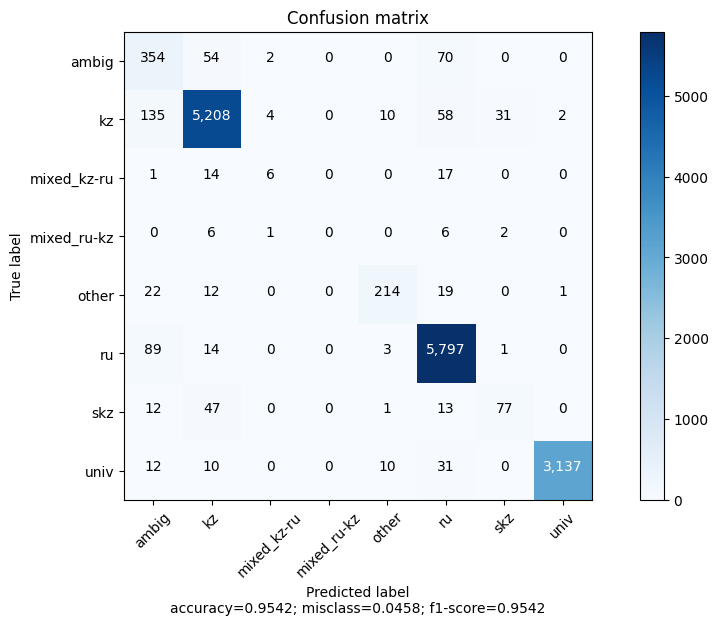

In [ ]:
from sklearn.metrics import confusion_matrix

tags = sorted(set(y_pred+y_true))
cnf_matrix = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(f1_score(y_true=y_true, y_pred=y_pred, average='micro'), cnf_matrix, target_names=tags, normalize=False)

## Publish model

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [ ]:
model.push_to_hub("liminovna/KazRusCSW-mbert")
tokenizer.push_to_hub("liminovna/KazRusCSW-mbert")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...tgs1qam/model.safetensors:   0%|          |  555kB /  711MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/liminovna/KazRusCSW_mbert/commit/cf7cd32b4eca1650c8d809a795dc5944ece4a1bd', commit_message='Upload tokenizer', commit_description='', oid='cf7cd32b4eca1650c8d809a795dc5944ece4a1bd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/liminovna/KazRusCSW_mbert', endpoint='https://huggingface.co', repo_type='model', repo_id='liminovna/KazRusCSW_mbert'), pr_revision=None, pr_num=None)